In [1]:
# Install timm if missing (run once, then restart kernel)
import subprocess, sys
try:
    import timm
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'timm'])
    import timm

import torch
print(f'timm  : {timm.__version__}')
print(f'torch : {torch.__version__}')
print(f'CUDA  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU   : {torch.cuda.get_device_name(0)}')
    print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

timm  : 1.0.25
torch : 2.9.0+cu128
CUDA  : True
GPU   : NVIDIA GeForce RTX 3070 Laptop GPU
VRAM  : 8.6 GB


In [1]:
import os, random, warnings
from pathlib import Path
from typing import List, Tuple
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [2]:
from pathlib import Path   # safety import — also defined in cell 2
import torch, numpy as np, random

# ── Paths ─────────────────────────────────────────────────────────────────────
# Dataset layout:
#   archive (2)/ecg data old version/ecg data old version/
#     train/   ← 3,023 images  (956 MI | 516 HistMI | 699 Abnormal | 852 Normal)
#     test/    ←   928 images  (239 MI | 172 HistMI | 233 Abnormal | 284 Normal)
#
# The "new version" is identical to old test — no additional data.
# We combine old train + old test (3,951 total) and do our own 80/20 split.

_OLD = Path(r'c:\Users\abdul\heart diagnose\archive (2)\ecg data old version\ecg data old version')
DATA_SOURCES = [_OLD / 'train', _OLD / 'test']

DEPLOY_ROOT = Path(r'c:\Users\abdul\heart diagnose\deploy')
SAVE_PATH   = DEPLOY_ROOT / 'models' / 'best_efficientnetv2s.pth'
SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)

# ── Hyperparameters ───────────────────────────────────────────────────────────
CFG = dict(
    img_size        = 300,
    num_classes     = 4,
    batch_size      = 32,      # 8 GB VRAM safe at 300×300 with fp16
    num_workers     = 0,
    val_split       = 0.20,
    seed            = 42,
    # Phase 1 — backbone frozen, head only
    epochs_p1       = 10,
    lr_p1           = 3e-4,
    # Phase 2 — last 30 % of backbone unfrozen
    epochs_p2       = 20,
    lr_p2           = 5e-5,
    # Phase 3 — full fine-tune at very low LR
    epochs_p3       = 15,
    lr_p3           = 1e-5,
    weight_decay    = 1e-4,
    dropout         = 0.40,
    label_smoothing = 0.10,
    mixed_precision = True,
)

torch.manual_seed(CFG['seed'])
np.random.seed(CFG['seed'])
random.seed(CFG['seed'])
print('Config ready.')
for src in DATA_SOURCES:
    print(f'  {"✓" if src.exists() else "✗ MISSING"} {src}')

Config ready.
  ✓ c:\Users\abdul\heart diagnose\archive (2)\ecg data old version\ecg data old version\train
  ✓ c:\Users\abdul\heart diagnose\archive (2)\ecg data old version\ecg data old version\test


train/ (3023 images)
  [0] Myocardial Infarction: 956
  [1] History of MI: 516
  [2] Abnormal Heartbeat: 699
  [3] Normal: 852
test/ (928 images)
  [0] Myocardial Infarction: 239
  [1] History of MI: 172
  [2] Abnormal Heartbeat: 233
  [3] Normal: 284

Combined total: 3951 images
  [0] Myocardial Infarction: 1195
  [1] History of MI: 688
  [2] Abnormal Heartbeat: 932
  [3] Normal: 1136


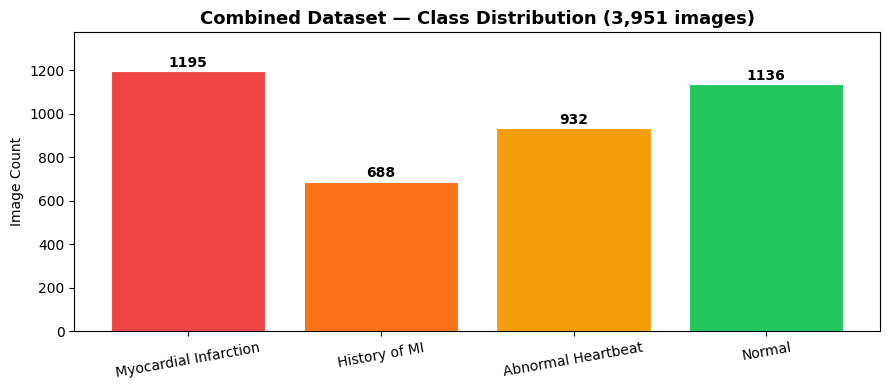


Train: 3160 | Val: 791


In [3]:
CLASS_NAMES = [
    'Myocardial Infarction',   # 0
    'History of MI',           # 1
    'Abnormal Heartbeat',      # 2
    'Normal',                  # 3
]

def folder_to_label(name: str):
    n = name.lower()
    if 'myocardial infarction' in n and 'history' not in n: return 0
    if 'history' in n:                                       return 1
    if 'abnormal' in n:                                      return 2
    if 'normal' in n:                                        return 3
    return None

def collect_samples(root: Path) -> List[Tuple[Path, int]]:
    samples = []
    for folder in sorted(root.iterdir()):
        if not folder.is_dir(): continue
        label = folder_to_label(folder.name)
        if label is None: continue
        for ext in ('*.jpg', '*.jpeg', '*.png', '*.bmp'):
            for p in folder.glob(ext):
                samples.append((p, label))
    return samples

# ── Collect from all sources and show per-source breakdown ───────────────────
all_samples = []
for src in DATA_SOURCES:
    subset = collect_samples(src)
    dist   = Counter(s[1] for s in subset)
    print(f'{src.name}/ ({len(subset)} images)')
    for i, name in enumerate(CLASS_NAMES):
        print(f'  [{i}] {name}: {dist[i]}')
    all_samples.extend(subset)

dist_total = Counter(s[1] for s in all_samples)
print(f'\nCombined total: {len(all_samples)} images')
for i, name in enumerate(CLASS_NAMES):
    print(f'  [{i}] {name}: {dist_total[i]}')

# ── Visualise class distribution ─────────────────────────────────────────────
colors = ['#ef4444', '#f97316', '#f59e0b', '#22c55e']
counts = [dist_total[i] for i in range(4)]
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(CLASS_NAMES, counts, color=colors, edgecolor='white', linewidth=0.8)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            str(cnt), ha='center', fontweight='bold')
ax.set_title('Combined Dataset — Class Distribution (3,951 images)', fontsize=13, fontweight='bold')
ax.set_ylabel('Image Count')
ax.tick_params(axis='x', rotation=10)
ax.set_ylim(0, max(counts) * 1.15)
plt.tight_layout()
plt.show()

# ── Stratified 80/20 split ───────────────────────────────────────────────────
train_samples, val_samples = train_test_split(
    all_samples,
    test_size=CFG['val_split'],
    random_state=CFG['seed'],
    stratify=[s[1] for s in all_samples],
)
print(f'\nTrain: {len(train_samples)} | Val: {len(val_samples)}')

In [4]:
import torchvision.transforms.v2 as v2

IMG_MEAN = (0.5, 0.5, 0.5)
IMG_STD  = (0.5, 0.5, 0.5)
SZ = CFG['img_size']

# Augmentation runs entirely on GPU — no CPU bottleneck
gpu_train_tfm = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(10),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    v2.RandomResizedCrop(SZ, scale=(0.85, 1.0), antialias=True),
    v2.Normalize(IMG_MEAN, IMG_STD),
])

gpu_val_tfm = v2.Compose([
    v2.Normalize(IMG_MEAN, IMG_STD),
])


class GPUDataLoader:
    """Pre-loads all images directly into GPU VRAM as uint8 tensors (~1.07 GB).
    Augmentation runs on GPU — CPU is no longer in the data-loading hot path."""

    def __init__(self, samples, transform=None, batch_size=32, shuffle=False, drop_last=False):
        self.transform  = transform
        self.batch_size = batch_size
        self.shuffle    = shuffle
        self.drop_last  = drop_last
        self.n          = len(samples)

        tensors = []
        for path, _ in tqdm(samples, desc='→ GPU VRAM', leave=False):
            img = Image.open(path).convert('RGB').resize((SZ, SZ), Image.BILINEAR)
            arr = np.asarray(img, dtype=np.uint8)
            t   = torch.from_numpy(arr).permute(2, 0, 1)  # [3, H, W] uint8
            tensors.append(t)

        self.images = torch.stack(tensors).to(DEVICE)   # [N, 3, H, W] uint8 in VRAM
        self.labels = torch.tensor([s[1] for s in samples], dtype=torch.long, device=DEVICE)
        mb = self.images.numel() / 1e6
        print(f'  {self.n} images → GPU VRAM ({mb:.0f} MB)')

    def __len__(self):
        return self.n // self.batch_size if self.drop_last else (self.n + self.batch_size - 1) // self.batch_size

    def __iter__(self):
        idx = torch.randperm(self.n, device=DEVICE) if self.shuffle else torch.arange(self.n, device=DEVICE)
        for start in range(0, self.n, self.batch_size):
            batch_idx = idx[start : start + self.batch_size]
            if self.drop_last and len(batch_idx) < self.batch_size:
                break
            imgs = self.images[batch_idx].float() / 255.0  # uint8 → float32 [0, 1]
            lbls = self.labels[batch_idx]
            if self.transform:
                imgs = self.transform(imgs)
            yield imgs, lbls


print('Loading dataset into GPU VRAM (one-time, ~15 s)...')
train_loader = GPUDataLoader(train_samples, gpu_train_tfm, CFG['batch_size'], shuffle=True,  drop_last=True)
val_loader   = GPUDataLoader(val_samples,   gpu_val_tfm,   CFG['batch_size'], shuffle=False, drop_last=False)
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Loading dataset into GPU VRAM (one-time, ~15 s)...


→ GPU VRAM:   0%|          | 0/3160 [00:00<?, ?it/s]

  3160 images → GPU VRAM (853 MB)


→ GPU VRAM:   0%|          | 0/791 [00:00<?, ?it/s]

  791 images → GPU VRAM (214 MB)
Train batches: 98 | Val batches: 25


In [5]:
class SEBlock(nn.Module):
    def __init__(self, channels, ratio=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // ratio, bias=False),
            nn.ReLU(),
            nn.Linear(channels // ratio, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        b, c = x.shape[:2]
        return x * self.fc(self.pool(x).view(b, c)).view(b, c, 1, 1)


class ECGModel(nn.Module):
    def __init__(self, num_classes=4, dropout=0.4):
        super().__init__()
        self.backbone = timm.create_model(
            'tf_efficientnetv2_s', pretrained=True,   # tf_ variant has hosted weights
            num_classes=0, global_pool='',
        )
        feat_dim = self.backbone.num_features  # 1280
        self.se  = SEBlock(feat_dim)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.gmp = nn.AdaptiveMaxPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(feat_dim, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.25),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.se(self.backbone(x))
        return self.classifier(self.gap(x).flatten(1) + self.gmp(x).flatten(1))


model = ECGModel(CFG['num_classes'], CFG['dropout']).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'Parameters: {total_params:.1f} M')

# Class weights for imbalanced data
train_labels = [s[1] for s in train_samples]
cw = compute_class_weight('balanced', classes=np.arange(CFG['num_classes']), y=train_labels)
class_weights = torch.tensor(cw, dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=CFG['label_smoothing'])
print(f'Class weights: {cw.round(3)}')

Parameters: 21.2 M
Class weights: [0.826 1.436 1.06  0.869]


In [6]:
def set_trainable(model, phase: int):
    if phase == 1:
        for p in model.backbone.parameters(): p.requires_grad = False
    elif phase == 2:
        params  = list(model.backbone.parameters())
        cutoff  = int(0.70 * len(params))
        for i, p in enumerate(params): p.requires_grad = (i >= cutoff)
    else:
        for p in model.backbone.parameters(): p.requires_grad = True
    for p in model.se.parameters():         p.requires_grad = True
    for p in model.classifier.parameters(): p.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Phase {phase}: {trainable / 1e6:.1f} M trainable params')


def make_opt_sch(model, lr, epochs):
    opt = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=CFG['weight_decay'],
    )
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr * 0.01)
    return opt, sch


# Use new torch.amp API (torch >= 2.4) to avoid deprecation warnings
_AMP_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

def train_phase(model, optimizer, scheduler, num_epochs, phase_name, best_val_acc=0.0):
    scaler = torch.amp.GradScaler(_AMP_DEVICE, enabled=CFG['mixed_precision'])

    for epoch in range(1, num_epochs + 1):
        # ── train ─────────────────────────────────────────────────────────────
        model.train()
        tl, tc, tt = 0.0, 0, 0
        for imgs, labels in tqdm(train_loader, desc=f'[{phase_name}] E{epoch}/{num_epochs} train', leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            with torch.amp.autocast(_AMP_DEVICE, enabled=CFG['mixed_precision']):
                logits = model(imgs)
                loss   = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            tl += loss.item() * imgs.size(0)
            tc += (logits.detach().argmax(1) == labels).sum().item()
            tt += imgs.size(0)
        scheduler.step()

        # ── val ───────────────────────────────────────────────────────────────
        model.eval()
        vl, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in tqdm(val_loader, desc=f'[{phase_name}] E{epoch}/{num_epochs} val', leave=False):
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                with torch.amp.autocast(_AMP_DEVICE, enabled=CFG['mixed_precision']):
                    logits = model(imgs)
                    loss   = criterion(logits, labels)
                vl += loss.item() * imgs.size(0)
                vc += (logits.argmax(1) == labels).sum().item()
                vt += imgs.size(0)

        val_acc = vc / vt
        print(
            f'[{phase_name}] E{epoch:02d}  '
            f'train_acc={tc/tt:.4f}  '
            f'val_loss={vl/vt:.4f}  '
            f'val_acc={val_acc:.4f}  '
            f'lr={scheduler.get_last_lr()[0]:.2e}'
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), SAVE_PATH)
            print(f'  ✓ Best saved ({val_acc:.4f})')

    return best_val_acc

In [9]:
print('=' * 60)
print('PHASE 1 — backbone frozen, SE block + classifier only')
print('=' * 60)
set_trainable(model, 1)
optimizer, scheduler = make_opt_sch(model, CFG['lr_p1'], CFG['epochs_p1'])
best_acc = train_phase(model, optimizer, scheduler, CFG['epochs_p1'], 'P1')

PHASE 1 — backbone frozen, SE block + classifier only
Phase 1: 1.0 M trainable params


[P1] E1/10 train:   0%|          | 0/98 [00:00<?, ?it/s]

[P1] E1/10 val:   0%|          | 0/25 [00:00<?, ?it/s]

[P1] E01  train_acc=0.9748  val_loss=0.5010  val_acc=0.9317  lr=2.93e-04
  ✓ Best saved (0.9317)


[P1] E2/10 train:   0%|          | 0/98 [00:00<?, ?it/s]

...

[P1] E9/10 val:   0%|          | 0/25 [00:00<?, ?it/s]

[P1] E09  train_acc=0.9821  val_loss=0.4628  val_acc=0.9646  lr=1.03e-05
  ✓ Best saved (0.9646)


[P1] E10/10 train:   0%|          | 0/98 [00:00<?, ?it/s]

[P1] E10/10 val:   0%|          | 0/25 [00:00<?, ?it/s]

[P1] E10  train_acc=0.9869  val_loss=0.5697  val_acc=0.9027  lr=3.00e-06


In [10]:
print('=' * 60)
print('PHASE 2 — last 30 % of backbone unfrozen')
print('=' * 60)
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE, weights_only=True))
set_trainable(model, 2)
optimizer, scheduler = make_opt_sch(model, CFG['lr_p2'], CFG['epochs_p2'])
best_acc = train_phase(model, optimizer, scheduler, CFG['epochs_p2'], 'P2', best_acc)

PHASE 2 — last 30 % of backbone unfrozen
Phase 2: 11.4 M trainable params


[P2] E1/20 train:   0%|          | 0/98 [00:00<?, ?it/s]

[P2] E1/20 val:   0%|          | 0/25 [00:00<?, ?it/s]

[P2] E01  train_acc=0.9793  val_loss=0.4910  val_acc=0.9456  lr=4.97e-05


[P2] E2/20 train:   0%|          | 0/98 [00:00<?, ?it/s]

...

[P2] E19/20 val:   0%|          | 0/25 [00:00<?, ?it/s]

[P2] E19  train_acc=0.9923  val_loss=0.4875  val_acc=0.9532  lr=8.05e-07


[P2] E20/20 train:   0%|          | 0/98 [00:00<?, ?it/s]

[P2] E20/20 val:   0%|          | 0/25 [00:00<?, ?it/s]

[P2] E20  train_acc=0.9892  val_loss=0.4565  val_acc=0.9469  lr=5.00e-07


In [11]:
print('=' * 60)
print('PHASE 3 — full fine-tune at very low LR')
print('=' * 60)
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE, weights_only=True))
set_trainable(model, 3)
optimizer, scheduler = make_opt_sch(model, CFG['lr_p3'], CFG['epochs_p3'])
best_acc = train_phase(model, optimizer, scheduler, CFG['epochs_p3'], 'P3', best_acc)
print(f'\nFinal best val_acc: {best_acc:.4f}')

PHASE 3 — full fine-tune at very low LR
Phase 3: 21.2 M trainable params


[P3] E1/15 train:   0%|          | 0/98 [00:00<?, ?it/s]

[P3] E1/15 val:   0%|          | 0/25 [00:00<?, ?it/s]

[P3] E01  train_acc=0.9876  val_loss=0.4916  val_acc=0.9267  lr=9.89e-06


[P3] E2/15 train:   0%|          | 0/98 [00:00<?, ?it/s]

...

[P3] E14/15 val:   0%|          | 0/25 [00:00<?, ?it/s]

[P3] E14  train_acc=0.9943  val_loss=0.4025  val_acc=0.9747  lr=2.08e-07


[P3] E15/15 train:   0%|          | 0/98 [00:00<?, ?it/s]

[P3] E15/15 val:   0%|          | 0/25 [00:00<?, ?it/s]

[P3] E15  train_acc=0.9946  val_loss=0.4115  val_acc=0.9823  lr=1.00e-07

Final best val_acc: 0.9861


Evaluating:   0%|          | 0/25 [00:00<?, ?it/s]

                       precision    recall  f1-score   support

Myocardial Infarction     1.0000    0.9665    0.9830       239
        History of MI     1.0000    0.9783    0.9890       138
   Abnormal Heartbeat     0.9842    1.0000    0.9920       187
               Normal     0.9660    1.0000    0.9827       227

             accuracy                         0.9861       791
            macro avg     0.9875    0.9862    0.9867       791
         weighted avg     0.9865    0.9861    0.9861       791



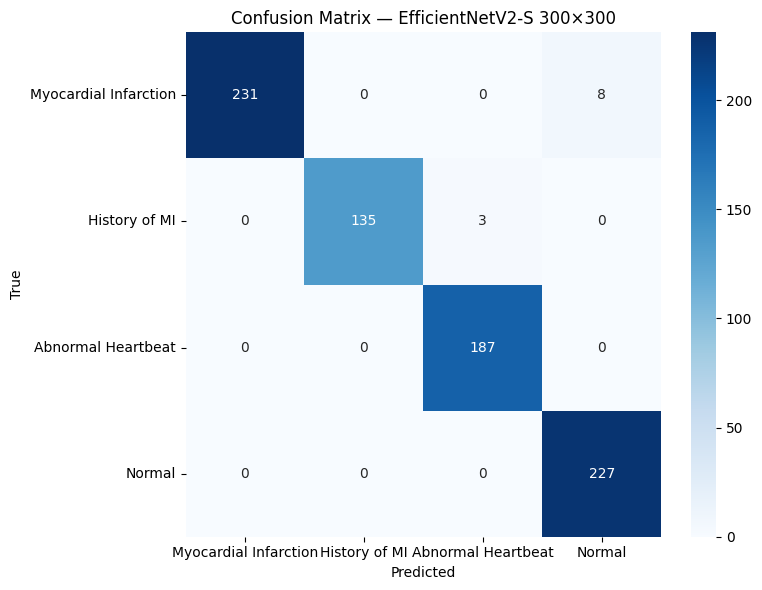

In [13]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE, weights_only=True))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc='Evaluating'):
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix — EfficientNetV2-S 300×300')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
import re

MODEL_PY = DEPLOY_ROOT / 'app' / 'model.py'
src = MODEL_PY.read_text(encoding='utf-8')

# Ensure path and IMG_SIZE are correct
src = re.sub(
    r'MODEL_PATH = .*',
    'MODEL_PATH = Path(__file__).parent.parent / "models" / "best_efficientnetv2s.pth"',
    src,
)
src = re.sub(
    r'IMG_SIZE = \(\d+, \d+\)',
    f'IMG_SIZE = ({CFG["img_size"]}, {CFG["img_size"]})',
    src,
)
MODEL_PY.write_text(src, encoding='utf-8')

print(f'✓ Model saved : {SAVE_PATH}')
print(f'✓ Val accuracy: {best_acc:.4f}')
print(f'✓ Patched     : {MODEL_PY}')
print('→ Restart the FastAPI server to load the new model.')

✓ Model saved : c:\Users\abdul\heart diagnose\deploy\models\best_efficientnetv2s.pth
✓ Val accuracy: 0.9861
✓ Patched     : c:\Users\abdul\heart diagnose\deploy\app\model.py
→ Restart the FastAPI server to load the new model.
